Loading base packages

In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import numpy as np

SEED = 0 # Random hyperparameter

### Loading data

In [3]:
df = pd.read_csv('../export_data/g20_exportdata_2018.csv', encoding='latin1')

Data reduction keeping only important variables

In [4]:
col = [
'refPeriodId',      # Period ID
'refYear',           # Reference Year
'refMonth',          # Reference Month
'reporterCode',      # Reporter (exporter) code
'reporterISO',       # Reporter (exporter) name
'flowCode',          # Type of flow (export)
'partnerCode',       # Partner (importer) code
'partnerISO',        # Partner (importer) name
'isOriginalClassification', # Export classification (TOTAL)
'cmdCode',           # Export type (commodities)
'cifvalue',          # Export value + transportation costs
'fobvalue',          # Export value (on board)
]

df = df[col]

We use `fobvalue` as it excludes transportation costs. `cifvalue` will instead be used to evaluate the goodness of our assumption regarding cost/distance parameters.

We rename `reporterISO` and `partnerISO` to match the naming in our successive geographical world graph 

In [5]:
name_to_change = ['USA','Türkiye','Rep. of Korea','Russian Federation']
changed_name = ['United States of America','Turkey','South Korea','Russia']

mapping = dict(zip(name_to_change, changed_name))

df['reporterISO'] = df['reporterISO'].replace(mapping)
df['partnerISO'] = df['partnerISO'].replace(mapping)

In [6]:
df['reporterCode'].value_counts() # checking whether all nations have data available for every partner

reporterCode
ARG    18
AUS    18
BRA    18
CAN    18
CHN    18
FRA    18
DEU    18
IDN    18
ITA    18
JPN    18
KOR    18
MEX    18
RUS    18
SAU    18
IND    18
ZAF    18
TUR    18
GBR    18
USA    18
Name: count, dtype: int64

Data scaling (reducing by a factor of $10^3$) *Dieci alla sesta?* for greater computational easeness 

In [7]:
#df[['cifvalue', 'fobvalue']] = df[['cifvalue', 'fobvalue']] / 1e6

### Trade flow graph

In [8]:
# Trade graph showing trade relations
G_trade = nx.from_pandas_edgelist(
    df, source='reporterCode', target='partnerCode', edge_attr='fobvalue',  create_using=nx.DiGraph()
)

Plotting

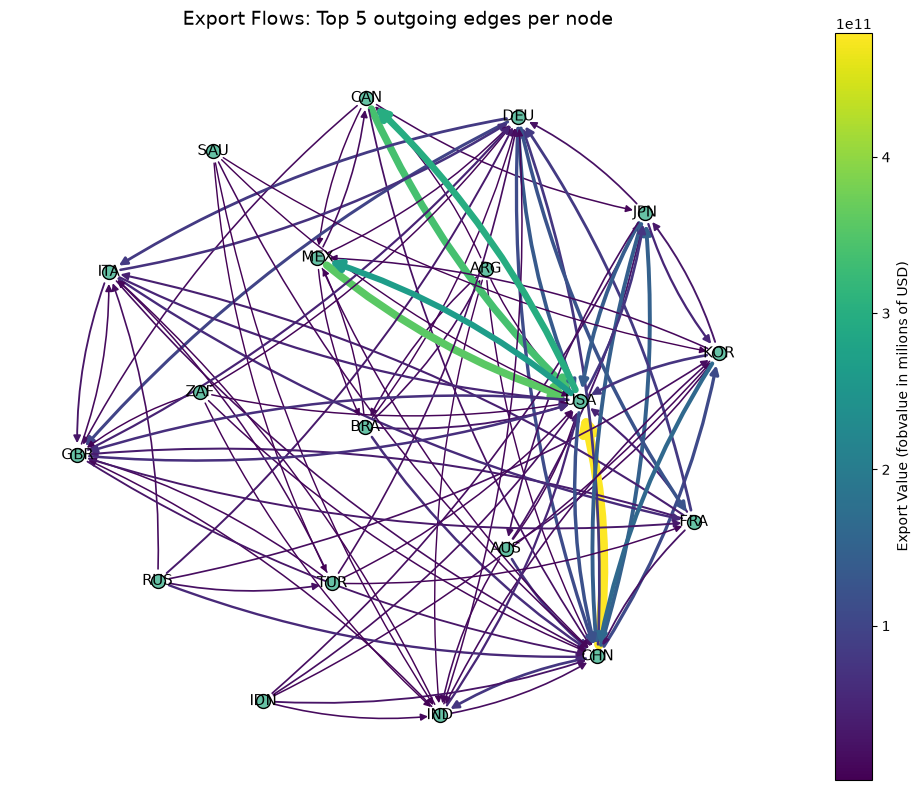

In [9]:
import matplotlib.pyplot as plt
import networkx as nx

fig, ax = plt.subplots(figsize=(10, 8))
pos = nx.spring_layout(G_trade, k=1, seed=SEED)

# --- Filter only top 5 export partner for each reporter ---
edgelist_to_draw = []
w = []

# Sorting of nodes according to 'fobvalue' values
for node, neighbors in G_trade.adjacency():
    # 'neighbors' dictionary with: {neighbors: {'fobvalue': value, ...}}
    # we sort neighbors on 'fobvalue' in decreasing order
    top_5 = sorted(
        neighbors.items(),
        key=lambda item: item[1].get('fobvalue', 0),
        reverse=True,
    )[:5]
# Top 5 extraction
    for neighbor, edge_data in top_5:
        edgelist_to_draw.append((node, neighbor))
        w.append(edge_data.get('fobvalue', 0))

# Normalization of arrows and thickness
if len(w) > 0:
    min_val, max_val = min(w), max(w)

    if min_val == max_val:
        arrow_sizes = [30] * len(w)
        edge_widths = [3] * len(w)
    else:
        # Arrow
        min_arrow, max_arrow = 10, 20
        arrow_sizes = [
            ((v - min_val) / (max_val - min_val)) * (max_arrow - min_arrow)
            + min_arrow
            for v in w
        ]

        # B Line thickness
        min_width, max_width = 1, 7
        edge_widths = [
            ((v - min_val) / (max_val - min_val)) * (max_width - min_width)
            + min_width
            for v in w
        ]
else:
    arrow_sizes, edge_widths = [], []
    min_val, max_val = 0, 1

# Plot
nx.draw_networkx_nodes(
    G_trade, pos, ax=ax, node_color='#66c2a5', node_size=100, edgecolors='black'
)
nx.draw_networkx_labels(
    G_trade, pos, ax=ax, font_size=11, font_family='sans-serif'
)

edges = nx.draw_networkx_edges(
    G_trade,
    pos,
    ax=ax,
    edgelist=edgelist_to_draw,
    edge_color=w,
    edge_cmap=plt.cm.viridis,
    width=edge_widths,
    arrowsize=arrow_sizes,
    connectionstyle='arc3,rad=0.1',
)

# Colorbar 
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.viridis, norm=plt.Normalize(vmin=min_val, vmax=max_val)
)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Export Value (fobvalue in milions of USD)')

plt.title(
    'Export Flows: Top 5 outgoing edges per node',
    fontsize=14,
)
plt.axis('off')
plt.tight_layout()
plt.show()

# World Graph Creation

We create a graph resembling the actual world structure. Meaning that edges will indicate that two points are contiguous on the world map

### Data fetching

In [10]:
import geopandas as gpd
from shapely.geometry import MultiPolygon, box, Point
url = "../countries/ne_110m_admin_0_countries.shp"
world = gpd.read_file(url)

# Selection of G20 nations
nations = ['Argentina','Australia','Brazil','Canada','China','France','Germany','India','Indonesia','Italy','Japan','Mexico','Russia','Saudi Arabia','South Africa','South Korea','Turkey','United Kingdom','United States of America']
g20 = world[world['NAME'].isin(nations)]

# Creation of Sea Boxes
seas_geometry = {
    'NAME': ['North Atlantic Ocean','South Atlantic Ocean', 'Mediterranean Sea', 'Black Sea', 'Baltic Sea', 'Norwegian/Barents Sea', 'Arabic Sea', 'Gulf of Bengal', 'West Indian Ocean', 'Indian Ocean', 'South/North Chinese Sea', 'Japanese Sea', 'Banda Sea', 'East Pacific Ocean', 'West Pacific Ocean', 'Caribbean Sea'],
    'geometry':[
        # 1. North Atlantic Ocean
        box(-80.0, 0.0, 0.0, 65.0),
        # 2. South Atlantic Ocean
        box(-70.0, -60.0, 20.0, 0.0),
        # 3. Mediterranean Sea
        box(-6.0, 30.0, 36.0, 46.0),
        # 4. Black Sea
        box(27.0, 40.5, 42.0, 47.0),
        # 5. Baltic Sea
        box(9.5, 53.5, 30.0, 66.0),
        # 6. Norwegian/Barents Sea
        box(-10.0, 62.0, 60.0, 80.0),
        # 7. Arabic Sea
        box(45.0, 0.0, 77.0, 25.0),
        # 8. Gulf of Bengal
        box(77.0, 5.0, 98.0, 23.0),
        # 9. West Indian Ocean (East Africa Coast and Madagascar)
        box(30.0, -35.0, 60.0, 12.0),
        # 10. Indian Ocean 
        box(60.0, -60.0, 115.0, 0.0),
        # 11. South/North Chinese Sea
        box(100.0, 0.0, 130.0, 40.0),
        # 12. Japanese Sea
        box(127.0, 34.0, 142.0, 52.0),
        # 13. Banda Sea
        box(124.0, -8.0, 132.0, -3.0),
        # 14. Pacific Ocean (Split in two beacuse of the 180 Meridian)
        box(130.0, -50.0, 180.0, 65.0),  # East
        box(-180.0, -50.0, -70.0, 65.0),  # West
        # 15. Caribbean Sea
        box(-88.0, 9.0, -60.0, 22.0),
    ],
}

seas = gpd.GeoDataFrame(seas_geometry, crs="EPSG:4326")

# Creation of Straits/Canals data
canal_geom = {
    'NAME' : ['Kiel', 'Gibiltrair', 'Suez', 'Dardanelles', 'Malacca', 'Magellan', 'Panama','Good Hope'],
    'geometry' : [
        Point(9.53, 54.36),   # Kiel Canal
        Point(-5.35, 35.98),  # Gibiltrair
        Point(32.34, 30.58),  # Suez Canal
        Point(26.40, 40.20),  # Dardanelles
        Point(101.50, 2.50),  # Malacca Strait
        Point(-70.90, -53.60),# Magellan Strait
        Point(-79.68, 9.08),  # Panama Canal
        Point(18.16,-34.12)   # Good Hope  
    ]
}

canals = gpd.GeoDataFrame(canal_geom, crs="EPSG:4326" )

### Graph generation

In [11]:
# Integrated Graph Creation
G = nx.Graph()

# Nations Nodes
for idx, row in g20.iterrows():
    G.add_node(
        row["NAME"],
        node_type="country",
        trasversal_cost = 0.0,
        pos=(row["geometry"].centroid.x, row["geometry"].centroid.y),
    )

# Seas Nodes
for idx, row in seas.iterrows():
    G.add_node(
        row["NAME"],
        node_type="sea",
        trasversal_cost = 0.0,
        pos=(row["geometry"].centroid.x, row["geometry"].centroid.y),
    )

# Canal Nodes
for idx, row in canals.iterrows():
    G.add_node(
        row['NAME'],
        node_type='canal/strait',
        trasversal_cost = 0.0,
        pos=(row['geometry'].x, row['geometry'].y)
    )

# Adjusting non representative centroids for particular cases
pos = nx.get_node_attributes(G, "pos")
custom_positions = {
    "Canada" : (-80, 47.5),
    #"China" : (30, 120),Afte
    "United States of America": (-100.0369, 38.9072),
    "France": (2.3522, 46.8566),
    "Russia": (100, 60), #(37.6173, 55.7558) COORDINATES USED TO HAVE THE CENTROID SET UN MOSCOW
}
# Updating personalized positions
for node, new_coords in custom_positions.items():
    if node in G:
        pos[node] = new_coords
        G.nodes[node]["pos"] = new_coords

# Country-country Edges
geoms_countries = g20["geometry"].values
names_countries = g20["NAME"].values
for i in range(len(g20)):
    for j in range(i + 1, len(g20)):
        if geoms_countries[i].touches(geoms_countries[j]):
            G.add_edge(names_countries[i], names_countries[j], edge_type="land")
# Country-sea Edges (Accesso Marittimo Nazione -> Mare)
for _, country in g20.iterrows():
    for _, sea in seas.iterrows():
        if country["geometry"].buffer(0.1).intersects(sea["geometry"]):
            G.add_edge(
                country["NAME"], sea["NAME"], edge_type="maritime_access"
            )
# Sea-sea Edges (Connessioni Dirette Mare -> Mare)
for i in range(len(seas)):
    for j in range(i + 1, len(seas)):
        if seas.iloc[i]["geometry"].intersects(seas.iloc[j]["geometry"]):
            G.add_edge(
                seas.iloc[i]["NAME"],
                seas.iloc[j]["NAME"],
                edge_type="sea_sea",
            )
# Canal/Strait-Sea Edges (Connessioni Stretto -> Mare Adiacente)
# Si applica un buffer di 1.0° al punto dello stretto per intercettare i mari confinanti
for _, canal in canals.iterrows():
    canal_buffer = canal["geometry"].buffer(1.0)
    for _, sea in seas.iterrows():
        if canal_buffer.intersects(sea["geometry"]):
            G.add_edge(canal["NAME"], sea["NAME"], edge_type="sea_strait")

print(
    f"Mixed Graph Created: {G.number_of_nodes()} Nodes, {G.number_of_edges()} Edges."
)

Mixed Graph Created: 43 Nodes, 83 Edges.


### Edge manipolation

Printing the edgelist


In [12]:
df_edges = nx.to_pandas_edgelist(G)

Some edges need to be removed (i.e. France-Brazil land border), others need to be added (i.e. Arabic sea-Mediterranean link)

In [13]:
# West pacific
remove = ['Caribbean Sea', 'North Atlantic Ocean', 'South Atlantic Ocean', 'Brazil', 'Russia']
for e in remove:
    if G.has_edge('West Pacific Ocean', e):
        G.remove_edge('West Pacific Ocean', e)

G.add_edge('West Pacific Ocean','Magellan', edge_type='sea_strait')

# Caribbean Sea
G.add_edge('United States of America', 'Caribbean Sea', edge_type='maritime_access')

# Panama
if G.has_edge('Panama','North Atlantic Ocean'):
    G.remove_edge('Panama','North Atlantic Ocean')

# Brazil
# removing land border with France (technically exists but not really relevant trade-wise)
if G.has_edge('Brazil', 'France'):
    G.remove_edge('Brazil', 'France')

# Mediterranean Sea
remove = ['Russia','North Atlantic Ocean','Black Sea']
for e in remove:
    if G.has_edge('Mediterranean Sea', e):
        G.remove_edge('Mediterranean Sea', e)

# Baltic Sea
if G.has_edge('Baltic Sea','Norwegian/Barents Sea'):
    G.remove_edge('Baltic Sea','Norwegian/Barents Sea')

# Linking Straits to Seas
G.add_edge('Kiel', 'North Atlantic Ocean', edge_type='sea_strait')
G.add_edge('Suez', 'Arabic Sea', edge_type='sea_strait')

# China
remove = ['Japanese Sea', 'East Pacific Ocean']
for e in remove:
    if G.has_edge('China', e):
        G.remove_edge('China', e)

# Indian Ocean
if G.has_edge('Indian Ocean', 'South/North Chinese Sea'):
    G.remove_edge('Indian Ocean', 'South/North Chinese Sea')

# Pacific Link
G.add_edge('West Pacific Ocean','East Pacific Ocean', edge_type='sea_sea')

# Malacca and Banda Sea
add = ['Gulf of Bengal', 'Banda Sea']
for e in add:
    G.add_edge('Malacca', e, edge_type='sea_strait')
G.add_edge('Banda Sea','Indian Ocean', edge_type='sea_sea')

# Good Hope Atlantic-Indian Linking
G.add_edge('Good Hope', 'West Indian Ocean', edge_type='sea_strait')

# Germany to Nort-atlantic Ocean MODIFICA DI GIOVANNI

G.add_edge('Germany', 'North Atlantic Ocean', edge_type='maritime_access')

### Visualization

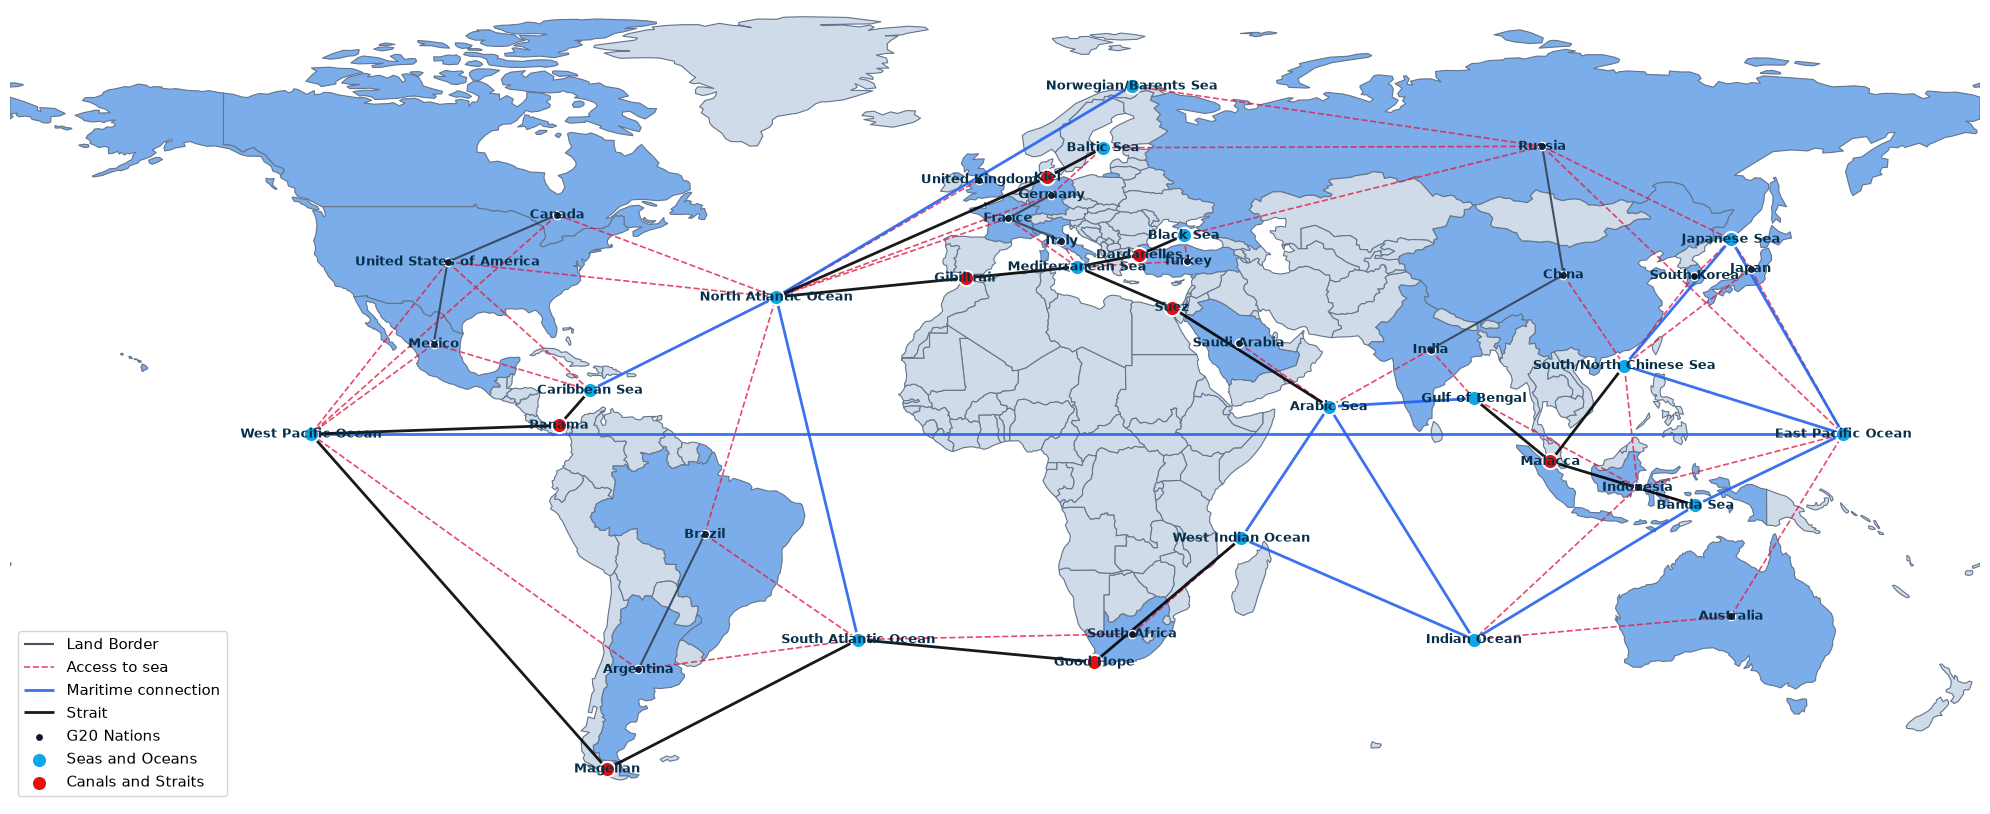

In [14]:

land_nodes = [n for n in G.nodes() if n in world["NAME"].values]
sea_nodes = [n for n in G.nodes() if n not in land_nodes]

# --- WORLD MAP AND HIGHLIGHTS ---
world.plot(ax=ax, color="#f8fafc", edgecolor="#e2e8f0", linewidth=0.5, zorder=1)

highlighted_nations = world[world["NAME"].isin(land_nodes)]
if highlighted_nations.empty:
    print("No highlighted nation in the daataset")

fig, ax = plt.subplots(figsize=(20, 10))

# --- NODES ---
land_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "country"]
sea_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "sea"]
strait_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "canal/strait"]



world.plot(ax=ax, color="#f8fafc", edgecolor="#e2e8f0", linewidth=0.5, zorder=1)

# Highlighting only selected nations
highlighted_nations = world[world["NAME"].isin(land_nodes)]
not_highlighted_nations = world[~world["NAME"].isin(land_nodes)]
highlighted_nations.plot(ax=ax, color="#7badeb", edgecolor="#64748b", linewidth=0.8, zorder=1)
not_highlighted_nations.plot(ax=ax, color="#cfdbe9", edgecolor="#64748b", linewidth=0.8, zorder=1)


# --- NODE POSITIONS AND EDGES DISCRIMINATION ---
pos = nx.get_node_attributes(G, "pos")

land_land_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("edge_type") == "land"]
land_sea_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("edge_type") == "maritime_access"]
sea_sea_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("edge_type") == "sea_sea" and {u, v}] #!= {"West Pacific Ocean", "East Pacific Ocean"}]
sea_strait_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("edge_type") == "sea_strait"]

# --- EDGES PLOT ---
nx.draw_networkx_edges(
    G, pos, edgelist=land_land_edges, ax=ax,
    edge_color="#334155", width=1.5, alpha=0.9, label="Land Border"
)
nx.draw_networkx_edges(
    G, pos, edgelist=land_sea_edges, ax=ax,
    edge_color="#e11d48", width=1.2, alpha=0.8, style="dashed", label="Access to sea"
)
nx.draw_networkx_edges(
    G, pos, edgelist=sea_sea_edges, ax=ax,
    edge_color="#2563eb", width=2.0, alpha=0.9, label="Maritime connection"
)

nx.draw_networkx_edges(
    G, pos, edgelist=sea_strait_edges, ax=ax,
    edge_color="#000000", width=2.0, alpha=0.9, label="Strait"
)

# --- NODES PLOT ---
# Land Nodes
nx.draw_networkx_nodes(
    G, pos, nodelist=land_nodes, ax=ax,
    node_size=35, node_color="#0f172a", edgecolors="white", linewidths=1, label="G20 Nations"
)
# Sea Nodes
nx.draw_networkx_nodes(
    G, pos, nodelist=sea_nodes, ax=ax,
    node_size=120, node_color="#0ea5e9", edgecolors="white", linewidths=1.5, label="Seas and Oceans"
)
# Strait Nodes
nx.draw_networkx_nodes(
    G, pos, nodelist=strait_nodes, ax=ax,
    node_size=120, node_color="#e90e0e", edgecolors="white", linewidths=1.5, label="Canals and Straits"
)

# --- LABELS ---
land_labels = {n: n for n in land_nodes}
nx.draw_networkx_labels(
    G, pos, labels=land_labels, ax=ax, 
    font_size=9, font_weight="bold", font_color="#082f49"
)
sea_labels = {n: n for n in sea_nodes}
nx.draw_networkx_labels(
    G, pos, labels=sea_labels, ax=ax, 
    font_size=9, font_weight="bold", font_color="#082f49"
)
strait_labels = {n: n for n in strait_nodes}
nx.draw_networkx_labels(
    G, pos, labels=strait_labels, ax=ax, 
    font_size=9, font_weight="bold", font_color="#082f49"
)

# --- FINAL PLOT SETTING ---
plt.title(
    "",
    fontsize=16,
    fontweight="bold",
)
plt.legend(loc="lower left", fontsize=11, frameon=True)
plt.xlim(-180, 180)
plt.ylim(-60, 85)
plt.axis("off")
plt.tight_layout()
plt.show()

# Edge Weighting

We need a way to assign a weight to each edge representing the cost of using that way to transport goods.

We first add non-plotted edges to link all countries with possible earth routes.

In [15]:
# Americas
# Canada-USA-Mexico to be linked with Brazil-Argentina
# Mexico-Brazil land link to be created
G.add_edge('Mexico','Brazil', edge_type='land')

# Africa
# Linking SouthAfrica to the rest of the world through Saudi Arabia
G.add_edge('South Africa', 'Saudi Arabia', edge_type='land')

# Europe
# Italy and Germany linked to both Russia and Turkey, and also between eachother
G.add_edge('Germany', 'Italy', edge_type='land')
G.add_edge('Germany', 'Turkey', edge_type='land')
G.add_edge('Germany', 'Russia', edge_type='land')
G.add_edge('Italy', 'Turkey', edge_type='land')
G.add_edge('Italy', 'Russia', edge_type='land')

# Middle East
# Linking Saudi Arabia to Turkey, Russia and India
G.add_edge('Saudi Arabia', 'Turkey', edge_type='land')
G.add_edge('Saudi Arabia', 'Russia', edge_type='land')
G.add_edge('Saudi Arabia', 'India', edge_type='land')
# Linking Turkey to India and Russia
G.add_edge('Turkey', 'Russia', edge_type='land')
G.add_edge('Turkey', 'India', edge_type='land')
# Linking India to Russia
G.add_edge('Russia', 'India', edge_type='land')

# Asia
# Linking China to South Korea and Russia
G.add_edge('China', 'Russia', edge_type='land')
G.add_edge('China', 'South Korea', edge_type='land')


Plotting our graph without political world map overlay (pure graph)

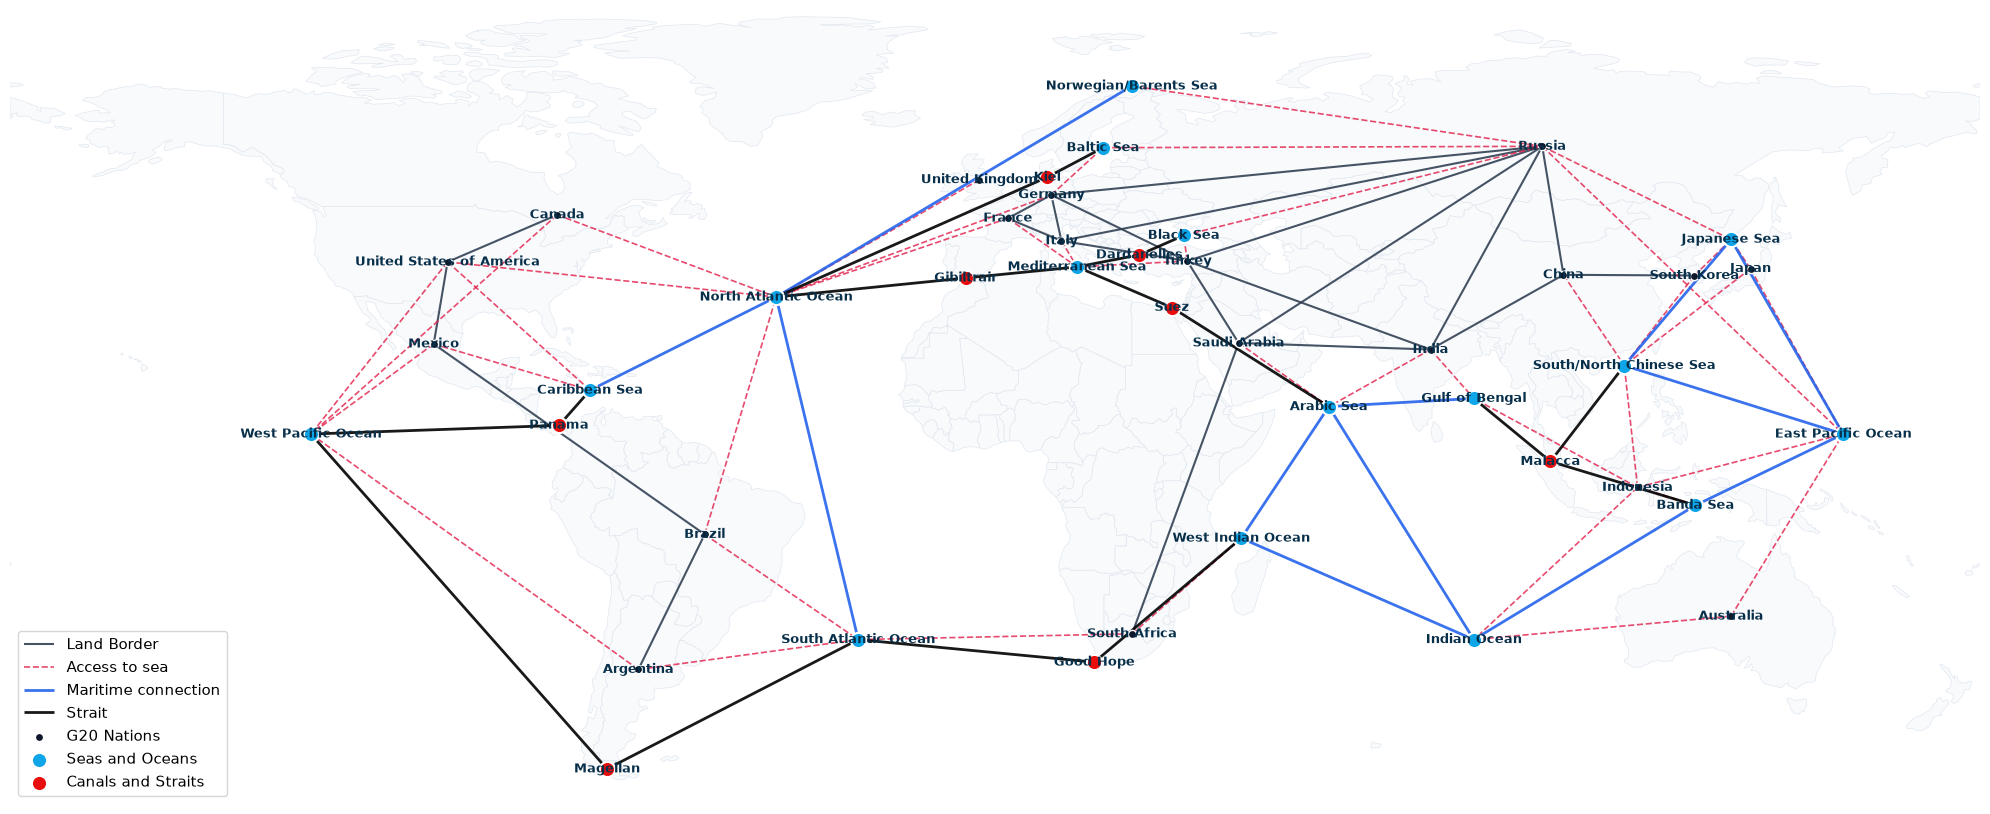

In [16]:
# --- WORLD MAP AND HIGHLIGHTS ---
world.plot(ax=ax, color="#f8fafc", edgecolor="#e2e8f0", linewidth=0.5, zorder=1)
fig, ax = plt.subplots(figsize=(20, 10))

# --- NODES ---
land_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "country"]
sea_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "sea"]
strait_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "canal/strait"]

world.plot(ax=ax, color="#f8fafc", edgecolor="#e2e8f0", linewidth=0.5, zorder=1)

# --- NODE POSITIONS AND EDGES DISCRIMINATION ---
pos = nx.get_node_attributes(G, "pos")

land_land_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("edge_type") == "land"]
land_sea_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("edge_type") == "maritime_access"]
sea_sea_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("edge_type") == "sea_sea" and {u, v} 
                 != {"West Pacific Ocean", "East Pacific Ocean"}] # avoiding middle line through plot
sea_strait_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("edge_type") == "sea_strait"]

# --- EDGES PLOT ---
nx.draw_networkx_edges(
    G, pos, edgelist=land_land_edges, ax=ax,
    edge_color="#334155", width=1.5, alpha=0.9, label="Land Border"
)
nx.draw_networkx_edges(
    G, pos, edgelist=land_sea_edges, ax=ax,
    edge_color="#e11d48", width=1.2, alpha=0.8, style="dashed", label="Access to sea"
)
nx.draw_networkx_edges(
    G, pos, edgelist=sea_sea_edges, ax=ax,
    edge_color="#2563eb", width=2.0, alpha=0.9, label="Maritime connection"
)
nx.draw_networkx_edges(
    G, pos, edgelist=sea_strait_edges, ax=ax,
    edge_color="#000000", width=2.0, alpha=0.9, label="Strait"
)

# --- NODES PLOT ---
# Land Nodes
nx.draw_networkx_nodes(
    G, pos, nodelist=land_nodes, ax=ax,
    node_size=35, node_color="#0f172a", edgecolors="white", linewidths=1, label="G20 Nations"
)
# Sea Nodes
nx.draw_networkx_nodes(
    G, pos, nodelist=sea_nodes, ax=ax,
    node_size=120, node_color="#0ea5e9", edgecolors="white", linewidths=1.5, label="Seas and Oceans"
)
# Strait Nodes
nx.draw_networkx_nodes(
    G, pos, nodelist=strait_nodes, ax=ax,
    node_size=120, node_color="#e90e0e", edgecolors="white", linewidths=1.5, label="Canals and Straits"
)

# --- LABELS ---
land_labels = {n: n for n in land_nodes}
nx.draw_networkx_labels(
    G, pos, labels=land_labels, ax=ax, 
    font_size=9, font_weight="bold", font_color="#082f49"
)
sea_labels = {n: n for n in sea_nodes}
nx.draw_networkx_labels(
    G, pos, labels=sea_labels, ax=ax, 
    font_size=9, font_weight="bold", font_color="#082f49"
)
strait_labels = {n: n for n in strait_nodes}
nx.draw_networkx_labels(
    G, pos, labels=strait_labels, ax=ax, 
    font_size=9, font_weight="bold", font_color="#082f49"
)

# --- FINAL PLOT SETTING ---
plt.title(
    "",
    fontsize=16,
    fontweight="bold",
)
plt.legend(loc="lower left", fontsize=11, frameon=True)
plt.xlim(-180, 180)
plt.ylim(-60, 85)
plt.axis("off")
plt.tight_layout()
plt.show()

Assign weight (distance) for edges

In [17]:
from math import asin, cos, radians, sin, sqrt


# --- HAVERSINE FUNCTION FOR GEOGRAPHICAL DISTANCE ---
def haversine_km(coord1, coord2):
    lon1, lat1 = coord1
    lon2, lat2 = coord2
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    return round(2 * 6371 * asin(sqrt(a)), 2)


# --- UPDATING GRAPH WEIGHTS ---
pos = nx.get_node_attributes(G, "pos")

for u, v in G.edges():
    if u in pos and v in pos:
        # Distance computation
        dist = haversine_km(pos[u], pos[v])
        G.edges[u, v]["weight"] = dist
    else:
        print(f"WARNING: missing coordinates between {u} and {v}")

edges_df = nx.to_pandas_edgelist(G)
print("\nPrime righe del DataFrame:")
print(edges_df.head())


Prime righe del DataFrame:
                     source                    target   weight  \
0                    Canada  United States of America  1876.10   
1                    Canada      North Atlantic Ocean  3739.60   
2                    Canada        West Pacific Ocean  6144.57   
3  United States of America                    Mexico  1681.93   
4  United States of America      North Atlantic Ocean  5370.64   

         edge_type  
0             land  
1  maritime_access  
2  maritime_access  
3             land  
4  maritime_access  


We choose a value of 5000$ per tonne of transported material, being thus able to extrapolate the approximate weight of total export for each country to each country. Such value is obtained taking the upperbound of average value for sea-transported goods and adding 2,000$ per tonnes, trying to incorporate and mitigate the distortion effect induced by high value, low weight goods (usually delivered through air transportation). 

In [18]:
# Transportation hyperparameters
# TODO fix costs computation (avoiding land-sea-land-sea hopping)
VALUE_PER_TONNE = 5000 # 5k dollars scaled as our export values
COST_PER_KM = 0.005 # assuming 0.005 dollars per kilometer
LAND_TRANSPORT_FACTOR = 100 # assuming land transportation to be 100 times more expensive
SEA_TO_LAND_COST_FACTOR = 4 #VALORE ORGININALE:1.5 assuming that landing and passing through a country is more expensive than circumnavigating it 

df['export_weight'] = df['fobvalue']/VALUE_PER_TONNE

# Transportation costs for each edge per tonne of material
#def TransportCost(G):
    #for u,v, data in G.edges(data=True):
        #edge_type = data.get('edge_type')
        #w = data.get('weight')
        #if edge_type in ['land']:
            #G.edges[u,v]['unit_cost'] = COST_PER_KM * LAND_TRANSPORT_FACTOR * w
        #elif edge_type == 'maritime_access':
            #G.edges[u,v]['unit_cost'] = COST_PER_KM * w * SEA_TO_LAND_COST_FACTOR
        #elif edge_type == 'sea_strait':
            #G.edges[u,v]['unit_cost'] = COST_PER_KM * w + G.nodes[u]["trasversal_cost"]/2 + G.nodes[v]["trasversal_cost"]/2 
        #else:
            #G.edges[u,v]['unit_cost'] = COST_PER_KM * w

def TransportCost(G):
    for u, v, data in G.edges(data=True):
        edge_type = data.get("edge_type")
        w = data.get("weight", 0)

        # Prende trasversal_cost in modo sicuro (0.0 se il nodo non lo possiede)
        cost_u = float(G.nodes[u].get("trasversal_cost", 0.0))
        cost_v = float(G.nodes[v].get("trasversal_cost", 0.0))

        if edge_type == "land":
            G.edges[u, v]["unit_cost"] = COST_PER_KM * LAND_TRANSPORT_FACTOR * w
        elif edge_type == "maritime_access":
            G.edges[u, v]["unit_cost"] = (COST_PER_KM * w * SEA_TO_LAND_COST_FACTOR)
        elif edge_type == "sea_strait":
            G.edges[u, v]["unit_cost"] = (COST_PER_KM *w + (cost_u / 2.0) + (cost_v / 2.0))
        else:
            G.edges[u, v]["unit_cost"] = COST_PER_KM * w

TransportCost(G)
edges_df = nx.to_pandas_edgelist(G)

## Distance Calculations

In [19]:
import heapq
def dijkstra(G, src):

    # Min-heap (priority queue) storing pairs of (distance, node)
    pq = []
    dist = {node: float("inf") for node in G.nodes()}
    path = {node: [] for node in G.nodes()}

    # Distance from source to itself is 0
    dist[src] = 0
    path[src] = [src]
    heapq.heappush(pq, (0, src))

    # Process the queue until all reachable vertices are finalized
    while pq:
        d, u = heapq.heappop(pq)

        # If this distance not the latest shortest one, skip it
        if d > dist[u]:
            continue

        # Explore all neighbors of the current vertex
        for v, edge_data in G[u].items():
            w = edge_data.get("unit_cost", float("inf"))

            # If we found a shorter path to v through u, update it
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                path[v] = path[u] + [v]
                heapq.heappush(pq, (dist[v], v))

    # Return the final shortest distances from the source
    return dist, path


#dijkstra used for strait trasversal cost#

def dijkstra_singletarget(G, src, target):
    pq = []
    dist = {node: float("inf") for node in G.nodes()}
    pred = {node: None for node in G.nodes()}

    dist[src] = 0
    heapq.heappush(pq, (0, src))

    while pq:
        d, u = heapq.heappop(pq)

        # Se abbiamo raggiunto il target, interrompiamo la ricerca
        if u == target:
            break

        if d > dist[u]:
            continue

        for v, edge_data in G[u].items():
            w = edge_data.get("unit_cost", float("inf"))

            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                pred[v] = u  # Memorizziamo solo il predecessore
                heapq.heappush(pq, (dist[v], v))

    # Se il target non è raggiungibile
    if dist[target] == float("inf"):
        return float("inf"), []

    # Ricostruzione del percorso a ritroso dal target a src
    path = []
    curr = target
    while curr is not None:
        path.append(curr)
        curr = pred[curr]
    path.reverse()

    return dist[target], path


Computing shortest distance (minimum weight distance) for every pair of `country` nodes

In [20]:
country_nodes = [
    n for n, d in G.nodes(data=True) if d.get("node_type") == "country"
]

results = []

for i, source in enumerate(country_nodes):

    dist, path = dijkstra(G, source)
    
    for target in country_nodes:
        d_val = dist[target]
        p_val = path[target]
        
        if d_val < float("inf"):
            edges_list = list(zip(p_val, p_val[1:]))
            
            results.append(
                {
                    "reporterISO": source,
                    "partnerISO": target,
                    "unit cost (per tonne)": round(d_val, 3),
                    "path": " -> ".join(p_val),
                    "edges_path": edges_list,
                    "hops": len(p_val) - 1, 
                }
            )
#paths_df = pd.DataFrame(results)
#print(paths_df.head(5))


#function form to be used later more elegantly#

def path_calculator(Graph = G, new = "original", percentage_fee = 0 , costly_strait = "Malacca"):

    country_nodes = [n for n, d in Graph.nodes(data=True) if d.get("node_type") == "country"]
    
    results = []

    for n in Graph.nodes():
        Graph.nodes[n]["trasversal_cost"] = 0.0

    Graph.nodes[costly_strait]["trasversal_cost"] = float((5000 * percentage_fee))

    TransportCost(Graph)

    for i, source in enumerate(country_nodes):
        for target in [n for n in country_nodes if n != source]:


            # 1. Estrazione del peso con estrazione esplicita dello scalare
            #match_val = df[
                #(df["reporterISO"] == source) & (df["partnerISO"] == target)]["export_weight"]

            #if not match_val.empty:
                # .iloc[0] prende il primo valore e float() garantisce che sia uno scalare puro
                #export_weight = float(match_val.iloc[0])
            #else:
                #export_weight = 0.0

            # 2. Resettiamo i trasversal_cost di tutti i nodi a 0.0 per evitare residui
            #for n in Graph.nodes():
                #Graph.nodes[n]["trasversal_cost"] = 0.0

            # 3. Assegniamo il costo scalare solo allo stretto selezionato
                #Graph.nodes[costly_strait]["trasversal_cost"] = float((5000 * percentage_fee))

            # 4. Ricalcolo dei pesi degli archi

            path = dijkstra_singletarget(Graph, source, target)

            d_val = path[0]
            p_val = path[1]
        
            if d_val < float("inf"):
                edges_list = list(zip(p_val, p_val[1:]))
            
                results.append(
                    {       
                        f"reporterISO": source,
                        f"partnerISO": target,
                        f"{new}unit cost (per tonne)": round(d_val, 3),
                        f"{new}path": " -> ".join(p_val),
                        f"{new}edges_path": edges_list,
                        f"{new}hops": len(p_val) - 1, 
                    }
                )
    paths_df = pd.DataFrame(results)

    return paths_df

paths_df = path_calculator(G, "", 0, "Suez")

## Costs, Profits and Visualization

Computing total costs for each Reporter-Partner relationship

In [21]:
df_final = pd.merge(df, paths_df, on=["reporterISO", "partnerISO"], how="inner")
df_final['TOTAL_transport_cost'] = df_final['export_weight']*df_final['unit cost (per tonne)']

Computing net profits. No negative profits to be found in base case

In [22]:
df_final['fobvalue'] = df_final['fobvalue']*1e-6
df_final['TOTAL_transport_cost'] = df_final['TOTAL_transport_cost']*1e-6
df_final['net_profit'] = df_final['fobvalue']-df_final['TOTAL_transport_cost']

Let's know add a counter to our edges in our graph G, in order to observe which edges are the most used in international trade

In [23]:

for u, v in G.edges():
    G.edges[u, v]["traversal_count"] = 0
    G.edges[u, v]["goods_value"] = 0

for edges_list, val in zip(df_final["edges_path"], df_final["fobvalue"]):
    for u, v in edges_list:
        G.edges[u, v]["traversal_count"] += 1
        G.edges[u, v]["goods_value"] += val

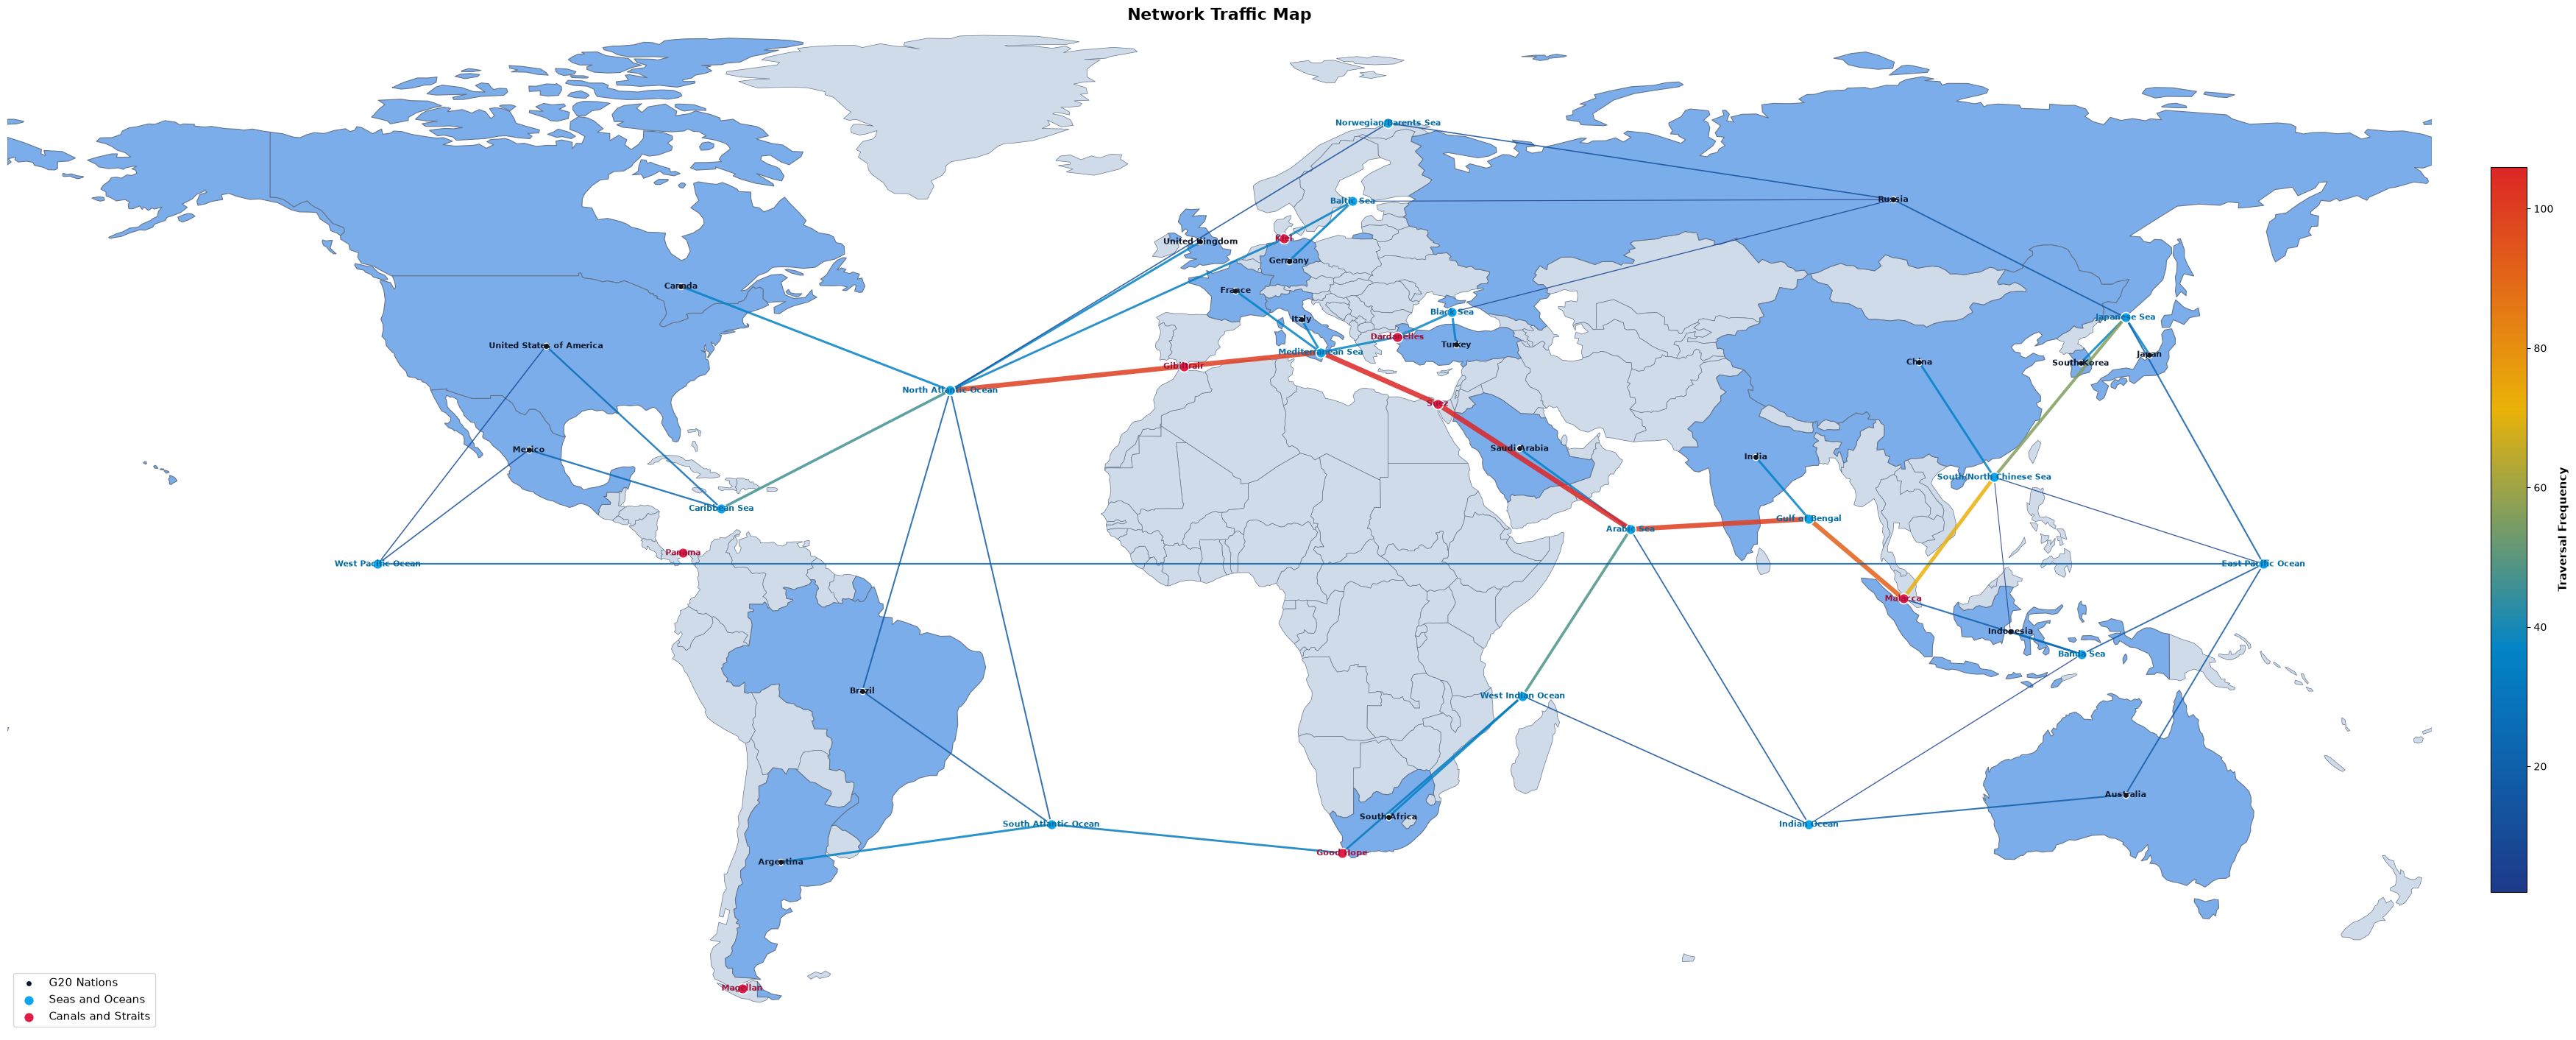

In [24]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(40, 20))

# Color scheme
custom_colors = ["#1e3a8a", "#0284c7", "#eab308", "#dc2626"]
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "BlueYellowRed", custom_colors
)

not_highlighted_nations.plot(ax=ax, color="#cfdbe9", edgecolor="#64748b", linewidth=0.5, zorder=1)
highlighted_nations.plot(ax=ax, color="#7badeb", edgecolor="#64748b", linewidth=0.8, zorder=1)

pos = nx.get_node_attributes(G, "pos")

# Count of traversal per edge
all_edges = [(u, v) for u, v in G.edges() if G.edges[u, v].get("traversal_count", 0) > 0]
traversal_counts = [ G.edges[u, v].get("traversal_count", 0) for u, v in all_edges]

min_count = min(traversal_counts) if traversal_counts else 0
max_count = max(traversal_counts) if traversal_counts else 1
if min_count == max_count:
    max_count += 1

# Dynamic Width
min_width, max_width = 0.8, 5.0
edge_widths = [
    min_width
    + (c - min_count) / (max_count - min_count) * (max_width - min_width)
    for c in traversal_counts
]

# ---EDGES PLOT WITH COLORMAP ---
drawn_edges = nx.draw_networkx_edges(
    G, pos, edgelist=all_edges, ax=ax,
    edge_color=traversal_counts, edge_cmap=custom_cmap,  
    edge_vmin=min_count, edge_vmax=max_count, width=edge_widths, alpha=0.85,
)

# --- NODES PLOT ---
nx.draw_networkx_nodes(
    G, pos, nodelist=land_nodes, ax=ax, 
    node_size=35, node_color="#0f172a", edgecolors="white", linewidths=1, label="G20 Nations",
)
nx.draw_networkx_nodes(
    G, pos, nodelist=sea_nodes, ax=ax,
    node_size=100, node_color="#0ea5e9", edgecolors="white", linewidths=1.2, label="Seas and Oceans",
)
nx.draw_networkx_nodes(
    G, pos, nodelist=strait_nodes, ax=ax,
    node_size=100, node_color="#e11d48", edgecolors="white", linewidths=1.2, label="Canals and Straits",
)

# --- LABELS ---
land_labels = {n: n for n in land_nodes}
sea_labels = {n: n for n in sea_nodes}
strait_labels = {n: n for n in strait_nodes}

# --- PLOT ---
nx.draw_networkx_labels(
    G,pos,labels=land_labels,ax=ax,font_size=8,font_weight="bold",font_color="#0f172a",
)
nx.draw_networkx_labels(
    G,pos,labels=sea_labels,ax=ax,font_size=8,font_weight="bold",font_color="#0369a1",
)
nx.draw_networkx_labels(
    G,pos,labels=strait_labels,ax=ax,font_size=8,font_weight="bold",font_color="#9f1239",
)

# --- COLORBAR ---
sm = plt.cm.ScalarMappable(
    cmap=custom_cmap, norm=mcolors.Normalize(vmin=min_count, vmax=max_count)
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label("Traversal Frequency", fontsize=11, fontweight="bold")

# Final settings
plt.title("Network Traffic Map", fontsize=16, fontweight="bold")
plt.legend(loc="lower left", fontsize=11, frameon=True)
plt.xlim(-180, 180)
plt.ylim(-60, 85)
plt.axis("off")
plt.tight_layout()
plt.show()

We also plot a map showing value transported per edge, to observe the "richest" edges in our world graph

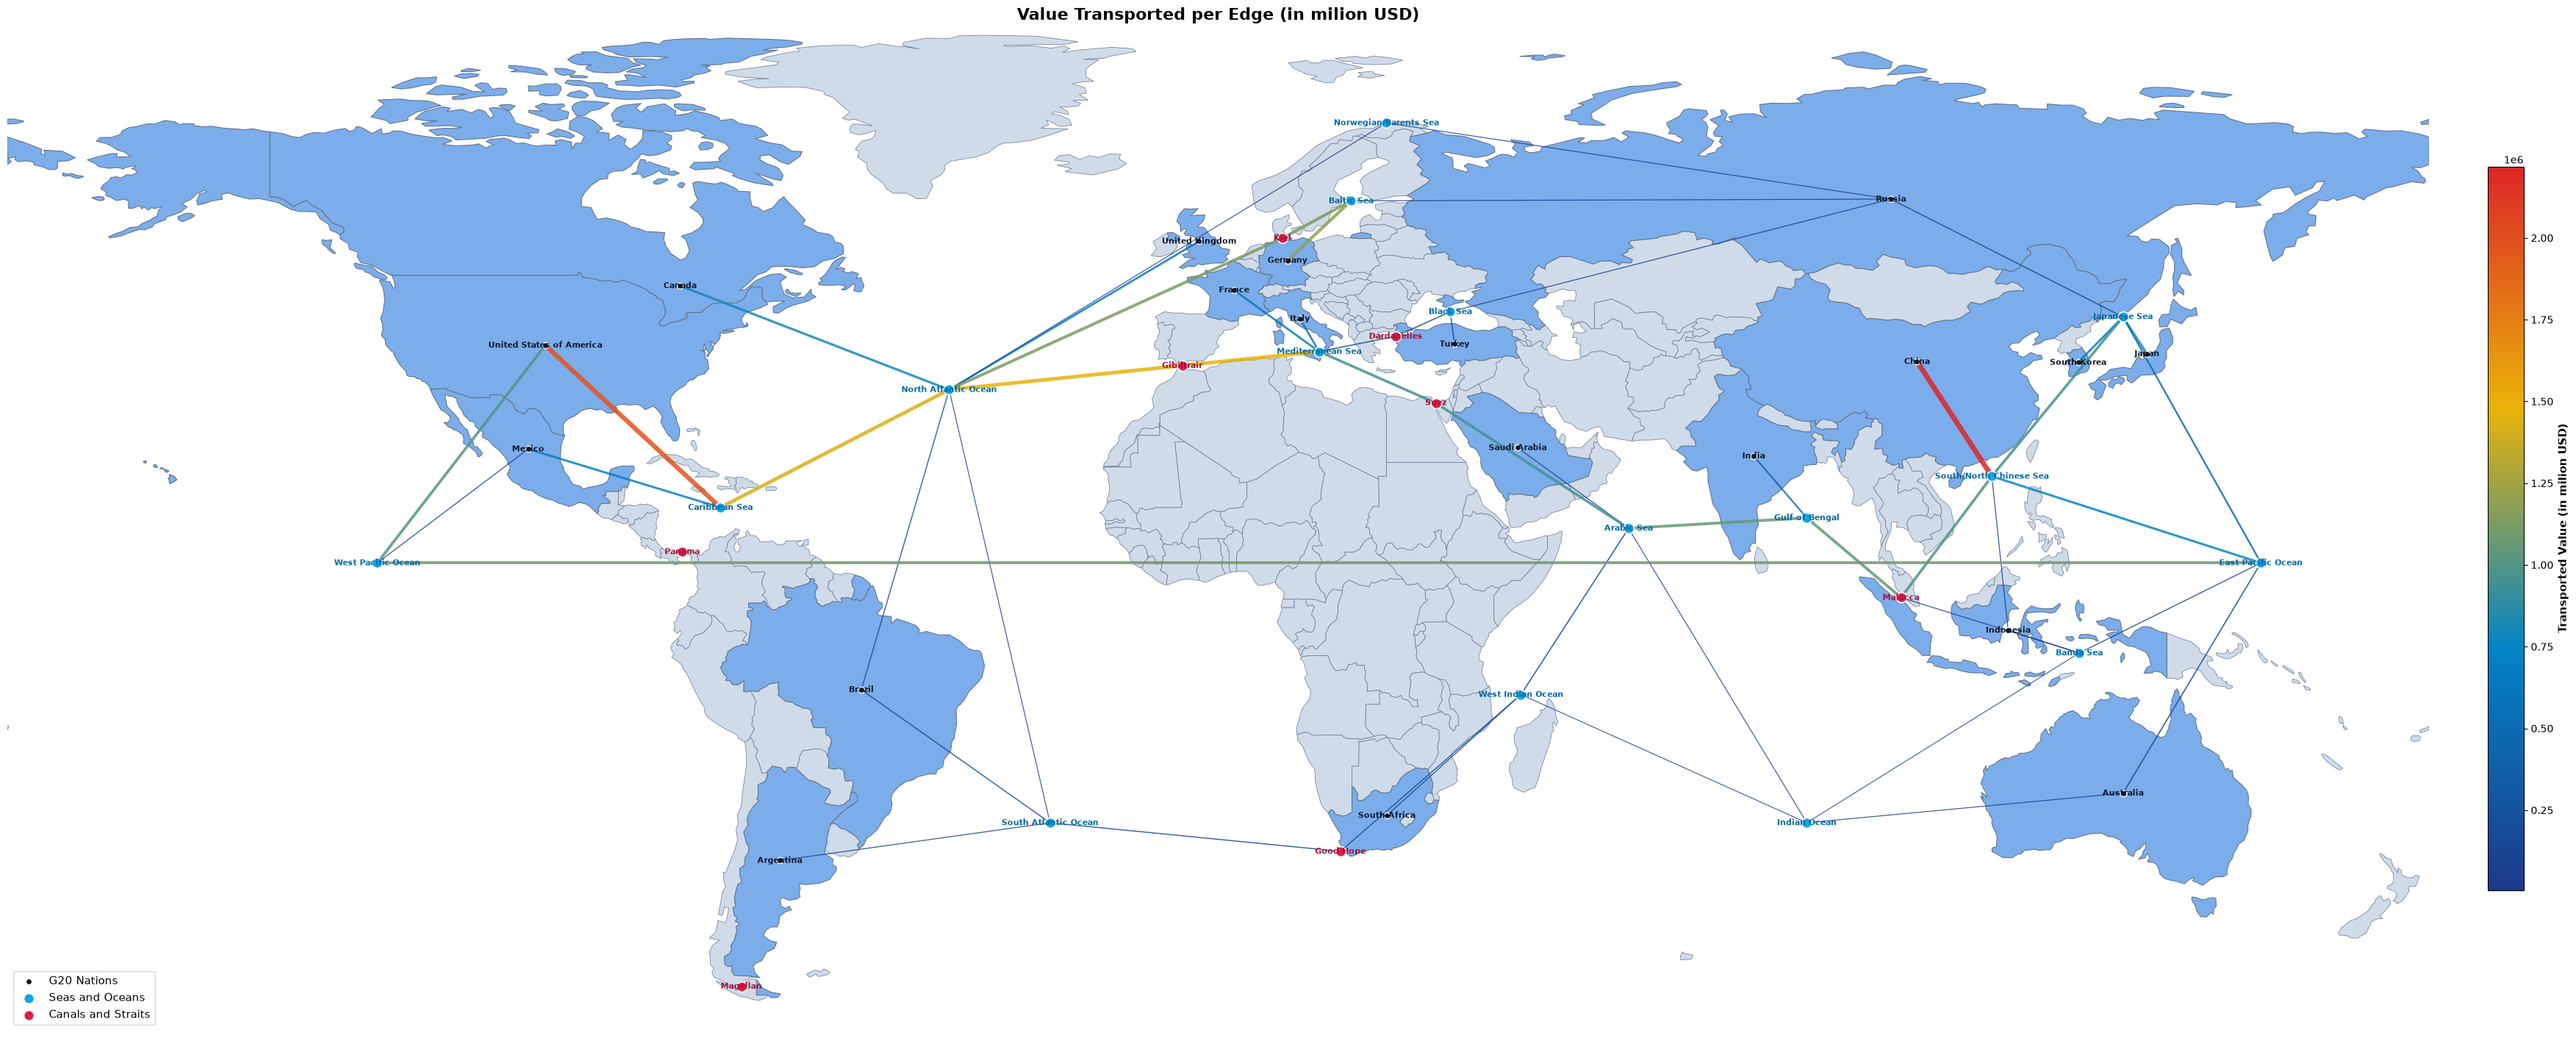

In [25]:
fig, ax = plt.subplots(figsize=(40, 20))

# Color scheme
custom_colors = ["#1e3a8a", "#0284c7", "#eab308", "#dc2626"]
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "BlueYellowRed", custom_colors
)

not_highlighted_nations.plot(ax=ax, color="#cfdbe9", edgecolor="#64748b", linewidth=0.5, zorder=1)
highlighted_nations.plot(ax=ax, color="#7badeb", edgecolor="#64748b", linewidth=0.8, zorder=1)

pos = nx.get_node_attributes(G, "pos")

# Value computation for active edges
all_edges = [
    (u, v) for u, v in G.edges() if G.edges[u, v].get("goods_value", 0) > 0
]
goods_value = [G.edges[u, v].get("goods_value", 0) for u, v in all_edges]

min_count = min(goods_value) if goods_value else 0
max_count = max(goods_value) if goods_value else 1

# Dynamic Width
min_width, max_width = 0.8, 5.0
edge_widths = [
    min_width
    + (c - min_count) / (max_count - min_count) * (max_width - min_width)
    for c in goods_value
]

# ---EDGES PLOT WITH COLORMAP ---
drawn_edges = nx.draw_networkx_edges(
    G, pos, edgelist=all_edges, ax=ax,
    edge_color=goods_value, edge_cmap=custom_cmap,  
    edge_vmin=min_count, edge_vmax=max_count, width=edge_widths, alpha=0.85,
)

# --- NODES PLOT ---
nx.draw_networkx_nodes(
    G, pos, nodelist=land_nodes, ax=ax, 
    node_size=35, node_color="#0f172a", edgecolors="white", linewidths=1, label="G20 Nations",
)
nx.draw_networkx_nodes(
    G, pos, nodelist=sea_nodes, ax=ax,
    node_size=100, node_color="#0ea5e9", edgecolors="white", linewidths=1.2, label="Seas and Oceans",
)
nx.draw_networkx_nodes(
    G, pos, nodelist=strait_nodes, ax=ax,
    node_size=100, node_color="#e11d48", edgecolors="white", linewidths=1.2, label="Canals and Straits",
)

# --- LABELS ---
land_labels = {n: n for n in land_nodes}
sea_labels = {n: n for n in sea_nodes}
strait_labels = {n: n for n in strait_nodes}

# --- PLOT ---
nx.draw_networkx_labels(
    G,pos,labels=land_labels,ax=ax,font_size=8,font_weight="bold",font_color="#0f172a",
)
nx.draw_networkx_labels(
    G,pos,labels=sea_labels,ax=ax,font_size=8,font_weight="bold",font_color="#0369a1",
)
nx.draw_networkx_labels(
    G,pos,labels=strait_labels,ax=ax,font_size=8,font_weight="bold",font_color="#9f1239",
)

# --- COLORBAR ---
sm = plt.cm.ScalarMappable(
    cmap=custom_cmap, norm=mcolors.Normalize(vmin=min_count, vmax=max_count)
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label("Transported Value (in milion USD)", fontsize=11, fontweight="bold")

# Final Settings
plt.title("Value Transported per Edge (in milion USD)", fontsize=16, fontweight="bold")
plt.legend(loc="lower left", fontsize=11, frameon=True)
plt.xlim(-180, 180)
plt.ylim(-60, 85)
plt.axis("off")
plt.tight_layout()
plt.show()

I want to see the phenomena of nation hopping, i will study briefly just a single country case

In [26]:
target = "Japan"

df_test = df_closure[df_closure["reporterISO"] == target]

fig, ax = plt.subplots(figsize=(40, 20))

# Color scheme
custom_colors = ["#1e3a8a", "#0284c7", "#eab308", "#dc2626"]
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "BlueYellowRed", custom_colors
)

not_highlighted_nations.plot(ax=ax, color="#cfdbe9", edgecolor="#64748b", linewidth=0.5, zorder=1)
highlighted_nations.plot(ax=ax, color="#7badeb", edgecolor="#64748b", linewidth=0.8, zorder=1)

pos = nx.get_node_attributes(G, "pos")


# ---EDGES PLOT WITH COLORMAP ---
drawn_edges = nx.draw_networkx_edges(
    G_changed, pos, edgelist=df_test["new edges_path"].explode().tolist(), ax=ax,
    edge_vmin=min_count, edge_vmax=max_count, width=edge_widths, alpha=0.85,
)

# --- NODES PLOT ---
nx.draw_networkx_nodes(
    G, pos, nodelist=land_nodes, ax=ax, 
    node_size=35, node_color="#0f172a", edgecolors="white", linewidths=1, label="G20 Nations",
)
nx.draw_networkx_nodes(
    G, pos, nodelist=sea_nodes, ax=ax,
    node_size=100, node_color="#0ea5e9", edgecolors="white", linewidths=1.2, label="Seas and Oceans",
)
nx.draw_networkx_nodes(
    G, pos, nodelist=strait_nodes, ax=ax,
    node_size=100, node_color="#e11d48", edgecolors="white", linewidths=1.2, label="Canals and Straits",
)

# --- LABELS ---
land_labels = {n: n for n in land_nodes}
sea_labels = {n: n for n in sea_nodes}
strait_labels = {n: n for n in strait_nodes}

# --- PLOT ---
nx.draw_networkx_labels(
    G,pos,labels=land_labels,ax=ax,font_size=8,font_weight="bold",font_color="#0f172a",
)
nx.draw_networkx_labels(
    G,pos,labels=sea_labels,ax=ax,font_size=8,font_weight="bold",font_color="#0369a1",
)
nx.draw_networkx_labels(
    G,pos,labels=strait_labels,ax=ax,font_size=8,font_weight="bold",font_color="#9f1239",
)

# --- COLORBAR ---
sm = plt.cm.ScalarMappable(
    cmap=custom_cmap, norm=mcolors.Normalize(vmin=min_count, vmax=max_count)
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label("Traversal Frequency", fontsize=11, fontweight="bold")

# Final settings
plt.title("Network Traffic Map", fontsize=16, fontweight="bold")
plt.legend(loc="lower left", fontsize=11, frameon=True)
plt.xlim(-180, 180)
plt.ylim(-60, 85)
plt.axis("off")
plt.tight_layout()
plt.show()



NameError: name 'df_closure' is not defined

CODE USED TO CALCULATE PATH VARIATION AFTER NODE ELIMINATION 

In [27]:

#simulation function, the function form is useful for cycle search of worst possible closure#

def closuresimulator(eliminated_node1, eliminated_node2, dataframe = df, graph = G):


    #FIRST ITERATION WITH EVERY NODE ACCESSIBLE#

    original_paths = path_calculator(graph, "original ")

    df_2turns = pd.merge(dataframe, original_paths, on=["reporterISO", "partnerISO"], how="inner")
    df_2turns['original_TOTAL_transport_cost'] = df_2turns['export_weight']*df_2turns['original unit cost (per tonne)']

    #SUBGRAPH CREATION#

    G_2 = graph.copy()
    for u, v in G_2.edges():
        G_2[u][v].pop("traversal_count", None)
    G_2.remove_edge(eliminated_node1, eliminated_node2)

#SECOND ITERATION WITH ELIMINATED NODE#

    new_paths = path_calculator(G_2, "new ")

    df_2turns = pd.merge(df_2turns, new_paths, on=["reporterISO", "partnerISO"], how="inner")
    df_2turns['new_TOTAL_transport_cost'] = df_2turns['export_weight']*df_2turns['new unit cost (per tonne)']
    df_2turns['cost_increase'] = df_2turns['new_TOTAL_transport_cost'] - df_2turns['original_TOTAL_transport_cost']


    for u, v in G_2.edges():
        G_2.edges[u, v]["traversal_count"] = 0
        G_2.edges[u, v]["goods_value"] = 0

    for edges_list, val in zip(df_2turns["new edges_path"], df_2turns["fobvalue"]):
        for u, v in edges_list:
            G_2.edges[u, v]["traversal_count"] += 1
            G_2.edges[u, v]["goods_value"] += val

    return G_2, df_2turns


test = closuresimulator('Gibiltrair', 'North Atlantic Ocean')

G_changed = test[0]
df_closure = test[1]


def taxsimulator(dataframe = df, graph = G, tax = 0, sea_strait = "Malacca"):


    #FIRST ITERATION WITH EVERY NODE ACCESSIBLE#

    original_paths = path_calculator(graph, "original ")

    df_2turns = pd.merge(dataframe, original_paths, on=["reporterISO", "partnerISO"], how="inner")
    df_2turns['original_TOTAL_transport_cost'] = df_2turns['export_weight']*df_2turns['original unit cost (per tonne)']

#SECOND ITERATION WITH INTRODUCED TAX#

    new_paths = path_calculator(G, "new ", tax, sea_strait)

    df_2turns = pd.merge(df_2turns, new_paths, on=["reporterISO", "partnerISO"], how="inner")
    df_2turns['new_TOTAL_transport_cost'] = df_2turns['export_weight']*df_2turns['new unit cost (per tonne)']
    df_2turns['cost_increase'] = df_2turns['new_TOTAL_transport_cost'] - df_2turns['original_TOTAL_transport_cost']


    for u, v in G.edges():
        G.edges[u, v]["traversal_count"] = 0
        G.edges[u, v]["goods_value"] = 0

    for edges_list, val in zip(df_2turns["new edges_path"], df_2turns["fobvalue"]):
        for u, v in edges_list:
            G.edges[u, v]["traversal_count"] += 1
            G.edges[u, v]["goods_value"] += val

    return G, df_2turns


test = taxsimulator(df, G, 0.018, "Suez")

G_changed = test[0]
df_closure = test[1]


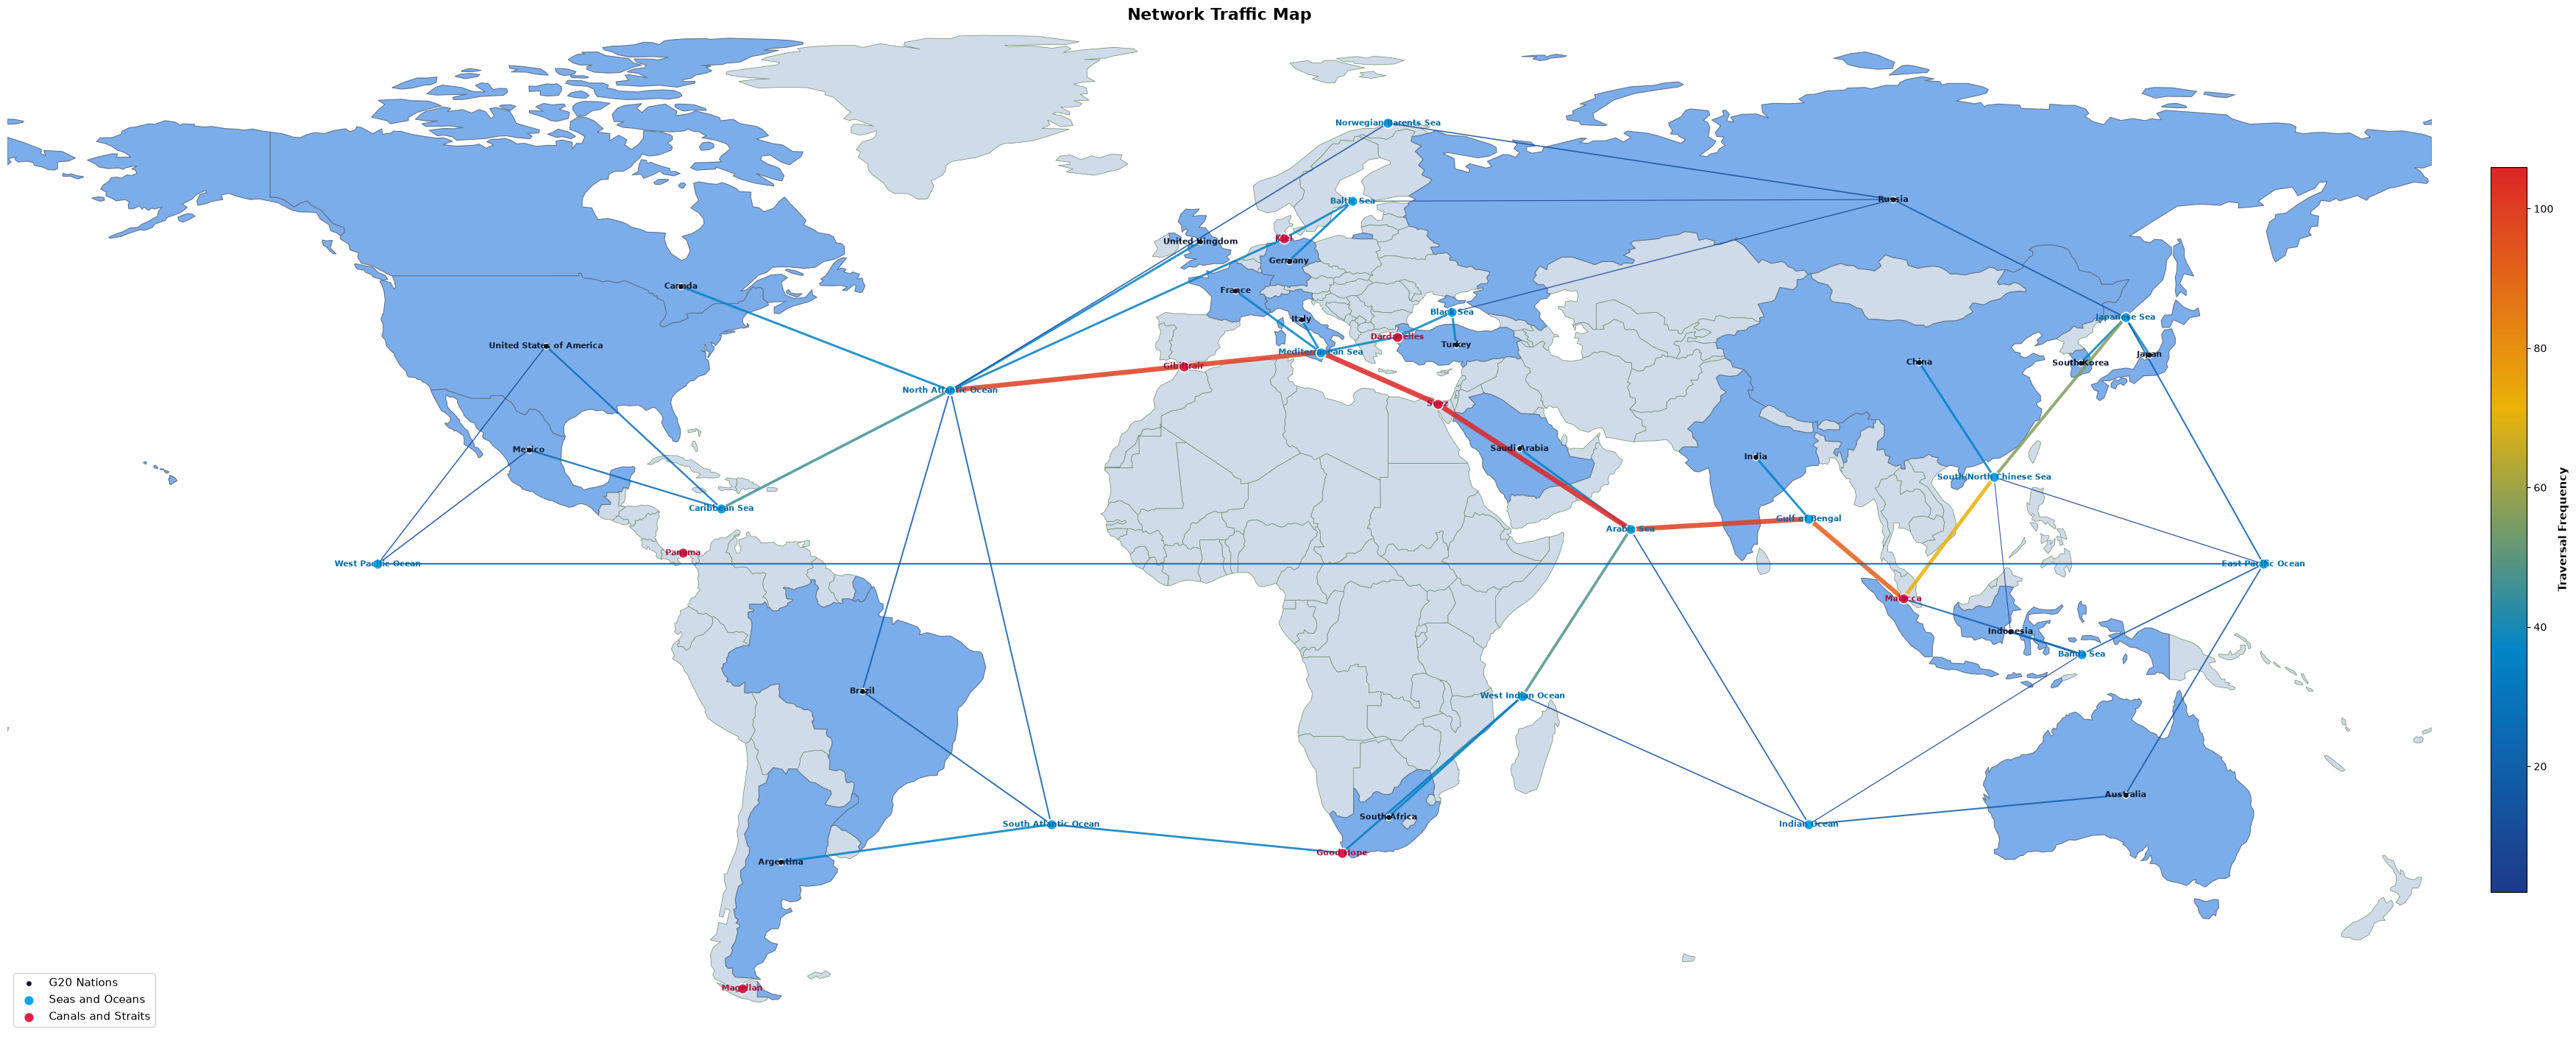

In [69]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(40, 20))

# Color scheme
custom_colors = ["#1e3a8a", "#0284c7", "#eab308", "#dc2626"]
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "BlueYellowRed", custom_colors
)

not_highlighted_nations.plot(ax=ax, color="#cfdbe9", edgecolor="#6d8b64", linewidth=0.5, zorder=1)
highlighted_nations.plot(ax=ax, color="#7badeb", edgecolor="#64748b", linewidth=0.8, zorder=1)

pos = nx.get_node_attributes(G, "pos")

# Count of traversal per edge
all_edges = [(u, v) for u, v in G_changed.edges() if G_changed.edges[u, v].get("traversal_count", 0) > 0]
traversal_counts = [ G_changed.edges[u, v].get("traversal_count", 0) for u, v in all_edges]

min_count = min(traversal_counts) if traversal_counts else 0
max_count = max(traversal_counts) if traversal_counts else 1
if min_count == max_count:
    max_count += 1

# Dynamic Width
min_width, max_width = 0.8, 5.0
edge_widths = [
    min_width
    + (c - min_count) / (max_count - min_count) * (max_width - min_width)
    for c in traversal_counts
]

# ---EDGES PLOT WITH COLORMAP ---
drawn_edges = nx.draw_networkx_edges(
    G_changed, pos, edgelist=all_edges, ax=ax,
    edge_color=traversal_counts, edge_cmap=custom_cmap,  
    edge_vmin=min_count, edge_vmax=max_count, width=edge_widths, alpha=0.85,
)

# --- NODES PLOT ---
nx.draw_networkx_nodes(
    G_changed, pos, nodelist=land_nodes, ax=ax, 
    node_size=35, node_color="#0f172a", edgecolors="white", linewidths=1, label="G20 Nations",
)
nx.draw_networkx_nodes(
    G_changed, pos, nodelist=sea_nodes, ax=ax,
    node_size=100, node_color="#0ea5e9", edgecolors="white", linewidths=1.2, label="Seas and Oceans",
)
nx.draw_networkx_nodes(
    G_changed, pos, nodelist=strait_nodes, ax=ax,
    node_size=100, node_color="#e11d48", edgecolors="white", linewidths=1.2, label="Canals and Straits",
)

# --- LABELS ---
land_labels = {n: n for n in land_nodes}
sea_labels = {n: n for n in sea_nodes}
strait_labels = {n: n for n in strait_nodes}

# --- PLOT ---
nx.draw_networkx_labels(
    G_changed,pos,labels=land_labels,ax=ax,font_size=8,font_weight="bold",font_color="#0f172a",
)
nx.draw_networkx_labels(
    G_changed,pos,labels=sea_labels,ax=ax,font_size=8,font_weight="bold",font_color="#0369a1",
)
nx.draw_networkx_labels(
    G_changed,pos,labels=strait_labels,ax=ax,font_size=8,font_weight="bold",font_color="#9f1239",
)

# --- COLORBAR ---
sm = plt.cm.ScalarMappable(
    cmap=custom_cmap, norm=mcolors.Normalize(vmin=min_count, vmax=max_count)
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label("Traversal Frequency", fontsize=11, fontweight="bold")

# Final settings
plt.title("Network Traffic Map", fontsize=16, fontweight="bold")
plt.legend(loc="lower left", fontsize=11, frameon=True)
plt.xlim(-180, 180)
plt.ylim(-60, 85)
plt.axis("off")
plt.tight_layout()
plt.show()

FINDING THE MOST CRUCIAL NODE IN THE GRAPH

In [28]:
list_of_nodes = G.nodes()

list_of_straits = [n for n, attr in G.nodes(data=True) if attr.get("node_type") == "canal/strait"]

i = 0

disaster_node = ["", ""]

for v in list_of_nodes:
    for u in list_of_straits:
        if [u,v] in G.edges():
            data = closuresimulator(u, v, df, G)[1]
            cost_sum = data["cost_increase"].sum()
            if cost_sum > i: 
                i = cost_sum
                disaster_node = [u,v]


print("the worst node is " + str(disaster_node) + "with a total cost of " + str(i))



the worst node is ['Gibiltrair', 'North Atlantic Ocean']with a total cost of 11005050846.43407


Finding the tax value that closes a strait

In [ ]:
list_of_nodes = G.nodes()

list_of_straits = [n for n, attr in G.nodes(data=True) if attr.get("node_type") == "canal/strait"]


def max_acceptable_tax(node, G = G, df = df): #Function that finds the max tax before closing a strait#

    i = 0

    node = node

    taxsimulator(df, G, 0, node)

    list_trasversals = [data.get("traversal_count", 0) for u, v, data in G.edges(node, data=True)]

    while list_trasversals != [0]*len(list_trasversals):
        i = i + 0.001
        taxsimulator(df, G, i, node)
        list_trasversals = [data.get("traversal_count", 0) for u, v, data in G.edges(node, data=True)]
        if list_trasversals == [0]*len(list_trasversals): 
            for n in np.arange(i - 0.001, i + 0.001, 0.0001):
                taxsimulator(df, G, n, node)
                list_trasversals = [data.get("traversal_count", 0) for u, v, data in G.edges(node, data=True)]
                if list_trasversals == [0]*len(list_trasversals):
                    return(n)


strait_max_tax = {}

for strait in list_of_straits: 
    tax = max_acceptable_tax(strait)
    print(tax)
    if tax != None:
        strait_max_tax[strait] = str(round(tax*100, 5)) + "%"
    else: 
        strait_max_tax[strait] = tax

print(strait_max_tax)



0.008299999999999998
0.016400000000000005
0.017800000000000003
0.0041
0.016900000000000002
None
None
0.008000000000000004
{'Kiel': '0.83%', 'Gibiltrair': '1.64%', 'Suez': '1.78%', 'Dardanelles': '0.41%', 'Malacca': '1.69%', 'Magellan': None, 'Panama': None, 'Good Hope': '0.8%'}


Finding the tax value that maximizes profits

In [90]:
def max_value_tax(node, G = G, df = df): #Function that finds the max tax before closing a strait#

    i = 0.0001

    node = node

    taxsimulator(df, G, 0, node)

    list_of_values = np.array([data.get("goods_value", 0) for u, v, data in G.edges(node, data=True)])

    print(list_of_values)

    tax_revenue = i*list_of_values

    total_revenue = sum(tax_revenue)

    best_tax = i

    while list_of_values.all() != 0:
        i = i + 0.0001
        taxsimulator(df, G, i, node)
        list_of_values = np.array([data.get("goods_value", 0) for u, v, data in G.edges(node, data=True)])
        new_total_revenue = sum(i*list_of_values)
        if new_total_revenue > total_revenue: 
            best_tax = i
            returns = list_of_values

    return(best_tax, str(returns))

print(max_value_tax("Malacca"))

[9.93422440e+11 1.05489168e+12 6.14692434e+10]
(0.0051, '[8.22401096e+11 8.22401096e+11 0.00000000e+00]')
